---
tags: [integration, optimization, variational]
---

# Qiskit Support

This page shows how to use Qamomile's [Qiskit](https://quantum-computing.ibm.com/docs/) quantum SDK integration through a concrete optimization problem.
Qiskit support is optional. Install the `qiskit` extra to use `QiskitTranspiler` and `QiskitExecutor`.
In this tutorial, we use QAOA optimization for a small MaxCut instance as an example. We transpile a Qamomile qkernel to a Qiskit circuit, then run sampling and expectation-value evaluation on a Qiskit simulator.
Along the way, we also look at several advanced Qiskit features.

In [1]:
# Install the latest Qamomile through pip.
# Install the Qiskit backend and circuit-visualization dependencies used below.
# !pip install "qamomile[qiskit,visualization]"

In [2]:
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.optimization.binary_model import BinaryModel
from qamomile.qiskit import QiskitTranspiler

## The MaxCut problem

We use the same small 5-node graph from the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb) so the focus stays on the Qiskit integration.
Maximizing $\sum_{(i,j) \in E}(1 - s_i s_j)/2$ is equivalent, up to a constant, to minimizing the antiferromagnetic Ising Hamiltonian $H_C = \sum_{(i,j) \in E} s_i s_j$.
For unweighted MaxCut, every $J_{ij} = 1$ and every $h_i = 0$, so we pass these coefficients directly to `BinaryModel.from_ising`.

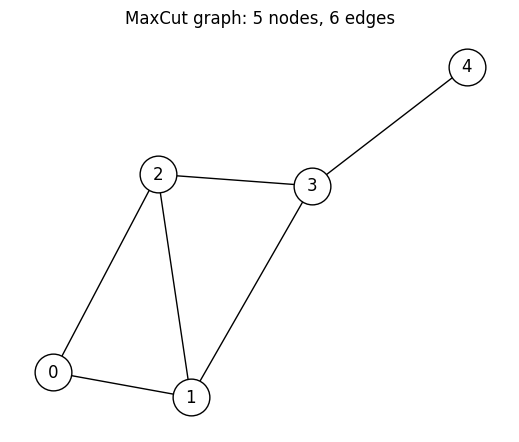

In [3]:
# Build the MaxCut graph and convert it to an Ising BinaryModel.
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# The problem structure is fully determined by the graph: one quad term per edge
# and no linear terms for unweighted MaxCut.
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## Building the QAOA ansatz with `@qkernel`

We write the QAOA quantum circuit for solving MaxCut as a `@qkernel`.
The recipe is the same as in the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb).
After preparing a uniform superposition in the computational basis, we alternately apply cost and mixer layers $p$ times, then measure in the computational basis.
The expectation-value qkernel is introduced later in the `run()` section so the circuit diagram below shows the sampling ansatz directly rather than a wrapper around a state-preparation helper.

:::{tip}
Qamomile's rotation gates follow the $e^{-i\theta/2}$ convention.
Because of that, the $1/2$ factor is handled slightly differently in the cost and mixer layers.
In the mixer layer, we pass $2\beta$ to `rx`, so the $1/2$ cancels and we get the textbook $e^{-i\beta X}$.
In the cost layer, we pass $J_{ij} \cdot \gamma$ to `rzz`, so the $1/2$ remains.
We absorb this coefficient difference into the variational parameter $\gamma$: the $\gamma$ used here is twice the textbook QAOA $\gamma$.
:::

In [4]:
# Prepare a uniform superposition over all graph nodes.
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)` renders the Qamomile circuit diagram.
We pass values for the arguments that determine the problem structure (`p`, `quad`, `linear`, `n`) so the number of layers and graph structure are reflected in the diagram.
Meanwhile, `gammas` / `betas` are left as parameters whose values are supplied later.

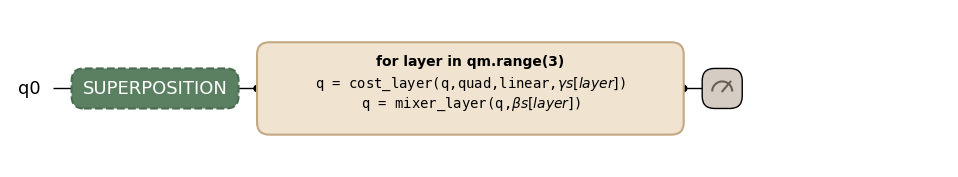

In [5]:
p = 3  # number of QAOA layers
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## Transpile to Qiskit

A quantum circuit defined as a Qamomile qkernel can be converted to a Qiskit `QuantumCircuit` with `QiskitTranspiler`.
You call `QiskitTranspiler.transpile()` the same way as with any other quantum SDK.
We bind the arguments that determine the problem structure and keep `gammas` / `betas` as runtime parameters.
For reproducible tutorial output, we specify an `AerSimulator` execution target with a fixed seed and `max_parallel_threads=1`.

In [6]:
SEED = 42


def make_seeded_backend() -> AerSimulator:
    return AerSimulator(seed_simulator=SEED, max_parallel_threads=1)


transpiler = QiskitTranspiler()

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()` returns the generated Qiskit `QuantumCircuit`.
The $2p$ QAOA angles (`gammas[0..p-1]`, `betas[0..p-1]`) remain as Qiskit `Parameter` objects until execution time.
Here we inspect the circuit transpiled into a Qiskit `QuantumCircuit` with Qiskit's text drawer.

In [7]:
# Inspect the generated circuit and verify that the parameters are still unbound.
qiskit_circuit = executable.get_first_circuit()
assert qiskit_circuit is not None
# QAOA uses one qubit and one final classical bit per graph node.
# The runtime parameters are one gamma and one beta per layer.
assert qiskit_circuit.num_qubits == num_nodes
assert qiskit_circuit.num_clbits == num_nodes
assert qiskit_circuit.num_parameters == 2 * p
assert set(executable.parameter_names) == {
    *(f"gammas[{i}]" for i in range(p)),
    *(f"betas[{i}]" for i in range(p)),
}
print(type(qiskit_circuit).__name__)
print("num_qubits    :", qiskit_circuit.num_qubits)
print("num_clbits    :", qiskit_circuit.num_clbits)
print("num_parameters:", qiskit_circuit.num_parameters)
print("parameters    :", sorted(str(param) for param in qiskit_circuit.parameters))

print(qiskit_circuit.draw(output="text", fold=120))

QuantumCircuit
num_qubits    : 5
num_clbits    : 5
num_parameters: 6
parameters    : ['betas[0]', 'betas[1]', 'betas[2]', 'gammas[0]', 'gammas[1]', 'gammas[2]']
     ┌───┐                                ┌────────────────┐                                                    »
q_0: ┤ H ├─■───────────────■──────────────┤ Rx(2*betas[0]) ├────────────────────────────────────■───────────────»
     ├───┤ │ZZ(gammas[0])  │              └────────────────┘                ┌────────────────┐  │ZZ(gammas[1])  »
q_1: ┤ H ├─■───────────────┼────────────────■────────────────■──────────────┤ Rx(2*betas[0]) ├──■───────────────»
     ├───┤                 │ZZ(gammas[0])   │ZZ(gammas[0])   │              └────────────────┘┌────────────────┐»
q_2: ┤ H ├─────────────────■────────────────■────────────────┼────────────────■───────────────┤ Rx(2*betas[0]) ├»
     ├───┤                                                   │ZZ(gammas[0])   │ZZ(gammas[0])  └────────────────┘»
q_3: ┤ H ├───────────────────────────────

Each runtime parameter remains unbound until execution time.
Binding `gammas` / `betas` is handled by `ExecutableProgram.sample(...)` and `ExecutableProgram.run(...)` through Qiskit's `assign_parameters`, so the Qiskit circuit can be created once and reused across many parameter vectors.
The problem structure, such as the Ising coefficients, qubit count, and number of layers, is fixed when the circuit is transpiled, leaving only the variational angles as runtime inputs.

## Sampling QAOA with `QiskitExecutor`

`executable.sample(executor, bindings=..., shots=...)` returns a `SampleJob`.
Calling `.result()` gives a `SampleResult`, which `BinaryModel.decode_from_sampleresult` decodes into a `BinarySampleSet` of spin variables $(+1 / -1)$.
This lets us count cut edges without any additional conversion.
`QiskitExecutor()` runs against `AerSimulator` by default when qiskit-aer is installed; here we use the seeded simulator from above.

In [8]:
rng = np.random.default_rng(SEED)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

# Sample the parameterized executable and decode bitstrings to Ising energies.
executor = transpiler.executor(backend=make_seeded_backend())
sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")
assert sample_result.shots == sample_shots

Mean energy at random init: -0.6840


## Optimizing the QAOA parameters

A QAOA optimization loop reuses the same `executable` across many `(gammas, betas)` vectors.
Call `transpiler.transpile()` once, then call `executable.sample()` many times.
In this example, we define the sampling and decoding work as `cost_fn()` and optimize it with SciPy's `minimize` function.
The classical optimization routine updates `(gammas, betas)` while lowering the mean sampled Ising energy.
Each iteration reuses the same `executable` and `QiskitExecutor`.

In [9]:
# Reuse one executable inside the classical objective function.
cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


# Optimize the sampled mean energy with COBYLA.
res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")
assert cost_history

Optimized mean energy: -2.8810
Optimal gammas       : [0.8678, -0.4364, 1.562]
Optimal betas        : [0.4086, -0.8709, 2.9557]


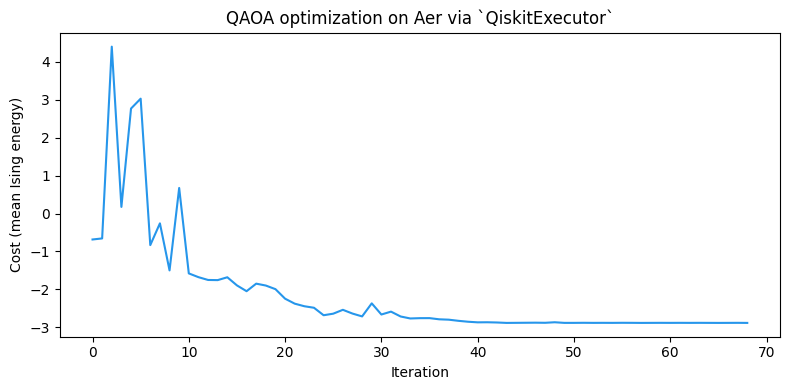

In [10]:
# Plot how the objective value changes during optimization.
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on Aer via `QiskitExecutor`")
plt.tight_layout()
plt.show()

Because the `AerSimulator` above was constructed with a fixed `seed_simulator`, re-running this page yields a reproducible sampling stream for the same sequence of circuits.
The optimizer should converge close to the ground-state energy of $H_C$ on this 5-node graph.
The optimized parameters from this run (`opt_gammas`, `opt_betas`) are reused throughout the rest of this page.

## Expectation values with `run()`

In Qamomile, you write expectation values in a qkernel with `qmc.expval(...)`.
When this is transpiled to Qiskit, it becomes an executable object that can be called with `ExecutableProgram.run(executor, bindings=...)`.
`run()` uses Qamomile's recorded parameter information to bind runtime parameters before calling Qiskit's estimator.

First build a Qamomile `Hamiltonian` for $H_C = \sum_{(i,j) \in E} Z_i Z_j$.
Then transpile the expectation-value qkernel and evaluate it at the optimized QAOA parameters.

In [11]:
# Build the Qamomile Hamiltonian that matches the MaxCut Ising cost.
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

# Define the expectation-value qkernel.
@qmc.qkernel
def qaoa_expval(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    obs: qmc.Observable,
) -> qmc.Float:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.expval(q, obs)


# Transpile the expectation-value qkernel and evaluate it with `run()`.
expval_executable = transpiler.transpile(
    qaoa_expval,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
        "obs": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
energy_via_run = expval_executable.run(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
).result()

print(f"Executable.run() expectation: {energy_via_run:+.10f}")
print(f"sample mean energy          : {res.fun:+.4f}")
assert np.isfinite(energy_via_run)

Executable.run() expectation: -2.8538574303
sample mean energy          : -2.8810


`ExecutableProgram.run(...)` is the recommended route when you work through the Qamomile API.
Direct `executor.estimate(...)` calls are still available when you intentionally manage Qiskit circuits yourself, but then you are responsible for Qiskit's parameter ordering and whether the circuit has already been bound.
`QiskitExecutor` creates Qiskit's `StatevectorEstimator` by default when it is available, so current Qiskit installs use the V2 primitive interface.
If a custom estimator, or an older Qiskit / Aer estimator, does not accept the V2 `run([(circuit, observable, params)])` call, Qamomile falls back to the V1 `run(circuits, observables, parameter_values)` form.

## Advanced Qiskit features

Qiskit is available through Qamomile's optional Qiskit integration.
Qamomile provides several ways to use advanced Qiskit features.

This section shows three features exposed by the Qiskit integration that are useful when running generated circuits on Qiskit execution targets:

- native classical control flow (`for_loop`, `if_else`, `while_loop`) for dynamic circuits,
- direct translation of parametric time evolution `qmc.pauli_evolve(...)` as a native `PauliEvolutionGate`,
- native `QFTGate` / inverse `QFTGate` for Qamomile's composite QFT operations.

### Classical control flow and runtime classical expressions

For Qamomile programs that use classical control flow and runtime classical expressions, the Qiskit integration can translate them directly into Qiskit's dynamic-circuit instructions and classical expressions.
`qmc.range(...)` loops become Qiskit `for_loop`.
Measurement-backed `if` / `else` and `while` become Qiskit dynamic-circuit instructions.
Compound predicates such as `a & b` can be converted directly into Qiskit classical expressions through `qiskit.circuit.classical.expr`.

In [12]:
# Define three small kernels that use native control-flow features.

# `qmc.range` for-loops become Qiskit `for_loop`.
@qmc.qkernel
def native_for_demo(reps: qmc.UInt) -> qmc.Bit:
    q = qmc.qubit("q")
    for _ in qmc.range(reps):
        q = qmc.h(q)
    return qmc.measure(q)


# Measurement-backed if branches become Qiskit `if_else`.
@qmc.qkernel
def runtime_branch_demo() -> qmc.Bit:
    a = qmc.qubit("a")
    b = qmc.qubit("b")
    target = qmc.qubit("target")

    a = qmc.x(a)
    b = qmc.x(b)
    ma = qmc.measure(a)
    mb = qmc.measure(b)

    if ma & mb:
        target = qmc.x(target)
    else:
        target = qmc.h(target)

    return qmc.measure(target)


# Measurement-backed while loops become Qiskit `while_loop`.
@qmc.qkernel
def repeat_until_zero_once() -> qmc.Bit:
    q0 = qmc.qubit("q0")
    q0 = qmc.x(q0)
    bit = qmc.measure(q0)
    while bit:
        q1 = qmc.qubit("q1")
        bit = qmc.measure(q1)
    return bit


# Transpile each demo and inspect the Qiskit operation names.
for_circuit = transpiler.to_circuit(native_for_demo, bindings={"reps": 3})
branch_circuit = transpiler.to_circuit(runtime_branch_demo)
while_circuit = transpiler.to_circuit(repeat_until_zero_once)

for_ops = [inst.operation.name for inst in for_circuit.data]
branch_ops = [inst.operation.name for inst in branch_circuit.data]
while_ops = [inst.operation.name for inst in while_circuit.data]

print("native_for_demo ops       :", for_ops)
print("runtime_branch_demo ops   :", branch_ops)
print("repeat_until_zero_once ops:", while_ops)
assert "for_loop" in for_ops
assert "if_else" in branch_ops
assert "while_loop" in while_ops

if_op = next(inst.operation for inst in branch_circuit.data if inst.operation.name == "if_else")
print("if_else condition:", if_op.condition)

native_for_demo ops       : ['for_loop', 'measure']
runtime_branch_demo ops   : ['x', 'x', 'measure', 'measure', 'if_else', 'measure']
repeat_until_zero_once ops: ['x', 'measure', 'while_loop']
if_else condition: Binary(Binary.<Op.LOGIC_AND: 4>, Var(<Clbit register=(3, "c"), index=0>, Bool()), Var(<Clbit register=(3, "c"), index=1>, Bool()), Bool())


Qiskit's classical expression system currently covers the logical, comparison, and arithmetic operations that Qamomile uses in dynamic conditions.
However, `FLOORDIV` and `POW` do not have matching Qiskit classical expressions, so target-legality verification raises `TargetCapabilityError` before Qiskit circuit construction if either one remains in a runtime condition.
If you need those operations, make sure their values are fixed before transpilation.

### Native `PauliEvolutionGate`

`qmc.pauli_evolve(q, H, gamma)` represents the time evolution $e^{-i\gamma H}$.
The Qiskit integration writes that operation as a `PauliEvolutionGate` when `use_native_pauli_evolution=True` (the default).
An unbound `gamma` becomes a Qiskit `Parameter`, so the same circuit can be reused while trying different variational parameters.

In [13]:
# Generate a Pauli evolution qkernel and check that Qiskit keeps it as one native operation.
@qmc.qkernel
def pauli_evolve_demo(
    n: qmc.UInt,
    H: qmc.Observable,
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Bit]:
    # Prepare a simple input state before applying the Hamiltonian evolution.
    q = qmc.qubit_array(n, "q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    q = qmc.pauli_evolve(q, H, gamma)
    return qmc.measure(q)


# Keep the Hamiltonian small so the generated operation is easy to inspect.
evolution_hamiltonian = qm_o.Z(0) * qm_o.Z(1) + 0.5 * qm_o.X(0)
evolution_executable = transpiler.transpile(
    pauli_evolve_demo,
    bindings={"n": evolution_hamiltonian.num_qubits, "H": evolution_hamiltonian},
    parameters=["gamma"],
)
evolution_circuit = evolution_executable.get_first_circuit()
assert evolution_circuit is not None
evolution_ops = [inst.operation.name for inst in evolution_circuit.data]
print(evolution_ops)
assert "PauliEvolution" in evolution_ops
assert {str(param) for param in evolution_circuit.parameters} == {"gamma"}

['h', 'h', 'PauliEvolution', 'measure', 'measure']


Pass `QiskitTranspiler(use_native_pauli_evolution=False)` when you want a gate-by-gate decomposition instead.
This flag controls only Pauli evolution. Native QFT/IQFT output is controlled independently by `use_native_composite`.

### Native `QFTGate`

Qamomile provides high-level operations for QFT and inverse QFT through `qmc.qft(...)` / `qmc.iqft(...)`.
The Qiskit integration can translate these qkernels directly to Qiskit's native `QFTGate`, without decomposing them into elementary quantum gates.
With `use_native_composite=False`, Qamomile keeps a named Qiskit gate backed by the portable fallback body. Call Qiskit's `decompose()` when you need to inspect its H/controlled-phase/SWAP implementation.

In [14]:
# Compare Qiskit's native QFT gate with a decomposed circuit.
@qmc.qkernel
def qft_demo(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, "q")
    q = qmc.qft(q)
    return qmc.measure(q)


qft_native = QiskitTranspiler(use_native_composite=True).to_circuit(
    qft_demo,
    bindings={"n": 3},
)
qft_decomposed = QiskitTranspiler(use_native_composite=False).to_circuit(
    qft_demo,
    bindings={"n": 3},
)
native_ops = [inst.operation.name for inst in qft_native.data]
decomposed_ops = [
    inst.operation.name for inst in qft_decomposed.decompose(reps=1).data
]
print("native QFT ops    :", native_ops)
print("decomposed QFT ops:", decomposed_ops)
assert any("qft" in name.lower() for name in native_ops)
assert "cp" in decomposed_ops
assert len(qft_native.data) < len(decomposed_ops)

native QFT ops    : ['qft', 'measure', 'measure', 'measure']
decomposed QFT ops: ['h', 'cp', 'h', 'cp', 'cp', 'h', 'swap', 'measure', 'measure', 'measure']


## Using other Qiskit execution targets

`QiskitExecutor` keeps the generated circuit separate from the Qiskit execution target that runs it.
By passing an execution target with `transpiler.executor(backend=...)`, you can run the same circuit on various Qiskit execution targets.
For example, you can use a noiseless local simulator, an Aer noise model, or a real quantum computer provided by IBM Quantum.

Here, we build an Aer noise model with depolarizing noise and pass it to `AerSimulator`.
We compare the clean and noisy sample-mean energies at the same optimized parameters.

In [15]:
# Build an Aer noise model with depolarizing noise on one- and two-qubit gates.
noise_model = NoiseModel()
one_qubit_error = depolarizing_error(0.01, 1)
two_qubit_error = depolarizing_error(0.02, 2)
noise_model.add_all_qubit_quantum_error(one_qubit_error, ["h", "rx", "rz"])
noise_model.add_all_qubit_quantum_error(two_qubit_error, ["rzz"])

noisy_backend = AerSimulator(
    noise_model=noise_model,
    seed_simulator=SEED,
    max_parallel_threads=1,
)
noisy_executor = transpiler.executor(backend=noisy_backend)

# Run the same executable on clean and noisy execution targets.
clean_result = executable.sample(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()
noisy_result = executable.sample(
    noisy_executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()

# Decode both sample sets to compare their mean Ising energies.
clean_energy = spin_model.decode_from_sampleresult(clean_result).energy_mean()
noisy_energy = spin_model.decode_from_sampleresult(noisy_result).energy_mean()
print(f"noiseless Aer mean energy: {clean_energy:+.4f}")
print(f"noisy Aer mean energy: {noisy_energy:+.4f}")
assert clean_result.shots == sample_shots
assert noisy_result.shots == sample_shots
assert np.isfinite(clean_energy)
assert np.isfinite(noisy_energy)

noiseless Aer mean energy: -2.8810
noisy Aer mean energy: -2.1370


## Summary

- `QiskitTranspiler().transpile(kernel, bindings=..., parameters=[...])` converts the qkernel to an `ExecutableProgram[QuantumCircuit]`; `to_circuit(...)` returns the Qiskit `QuantumCircuit` directly when you want to stay inside the Qiskit ecosystem.
- `QiskitExecutor` supports both `executable.sample()` for measured qkernels and `executable.run()` / `executor.estimate(...)` for expectation values, using `AerSimulator` by default and accepting any Qiskit execution target object through `transpiler.executor(backend=...)`.
- The Qiskit integration uses native mid-circuit measurement, dynamic `for_loop` / `if_else` / `while_loop`, runtime classical expressions, `PauliEvolutionGate`, and `QFTGate` where Qiskit provides a high-level representation.
- Aer noise models, provider execution targets, and qBraid-wrapped Qiskit devices can be used without re-transpiling the qkernel; Qamomile's optimization helpers use the same Qiskit circuit interface.

### See also

- [CUDA-Q Support](cudaq_support.ipynb) covers the same MaxCut QAOA workflow with CUDA-Q, including CUDA-Q targets and `observe`.
- [QURI Parts Support](quri_parts_support.ipynb) covers the same workflow on QURI Parts, including Qulacs sampling and QURI Parts estimator paths.